# **Late Delivery Risk**

## **Overview**

📦 **Task Overview**

This dataset contains over 180,000 transactions across three years from a global supply chain, including features about orders, products, shipping, delivery, and financials. Our primary task is to **predict Late Delivery Risk**, i.e., whether a particular order is likely to be delivered late.

🔍 **Importance of the Task**

Predicting late deliveries is crucial for supply chain efficiency, cost reduction, and customer satisfaction. By identifying orders at risk of delay, companies can take proactive actions, optimize logistics, improve resource allocation, and enhance service reliability.

🧾 **Key Features**

- Order Details: Order ID, product ID, quantity, price, discount, profit margins.
- Customer Information: Customer ID, location, contact details.
- Shipping Information: Shipping mode, shipping date, delivery date, shipping cost.
- Product Details: Category, brand, specifications.
- Financial Metrics: Total sales, total profit, profit margins.
- Delivery Performance: Delivery status (on-time or late), delivery delay duration.

These features allow us to analyze factors contributing to delivery delays and build models to predict the risk of late deliveries, enabling better decision-making and operational improvements.

## **Import Libraries and Download Data**

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
from matplotlib.ticker import FuncFormatter
import plotly.express as px

import missingno as msno

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import shap

!pip install lime
import lime
import lime.lime_tabular

!pip install dice-ml
import dice_ml
from dice_ml import Dice

import warnings
warnings.filterwarnings('ignore') # ignore warnings
pd.set_option('display.max_columns', None) # to display the total number columns present in the dataset

In [ ]:
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets download shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
!unzip /content/dataco-smart-supply-chain-for-big-data-analysis.zip

In [47]:
df = pd.read_csv("APL_Logistics.csv", encoding='latin1')
  # Load the dataset into a DataFrame

## **Exploratory Data Analysis (EDA)**

In [48]:
df.head(5) # Display the first 5 rows of the dataset to preview the data

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [49]:
df.shape # Display the dimensions of the dataset (rows, columns)

(180519, 40)

The dataset contains 180,519 rows (individual orders) and 53 columns (features).

In [50]:
df.describe().transpose()  # Get summary statistics for each column and transpose for better readability

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.980000,7.000000,31.520000,64.800000,911.800000
Sales per customer,180519.0,183.107607,120.043668,7.490000,104.380000,163.990000,247.400000,1939.990000
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [51]:
df.duplicated().sum()

np.int64(0)

---

In [52]:
df['Late_delivery_risk'].value_counts()  # Count the number of samples in each class

,count
Late_delivery_risk,
1,98977
0,81542


In [53]:
# Calculate and print the percentage of No Late_delivery_risk
print('No Late Delivery', round(df['Late_delivery_risk'].value_counts()[0] / len(df) * 100, 2), '% of the dataset')

# Calculate and print the percentage of Late_delivery_risk
print('Late Delivery', round(df['Late_delivery_risk'].value_counts()[1] / len(df) * 100, 2), '% of the dataset')

No Late Delivery 45.17 % of the dataset
Late Delivery 54.83 % of the dataset


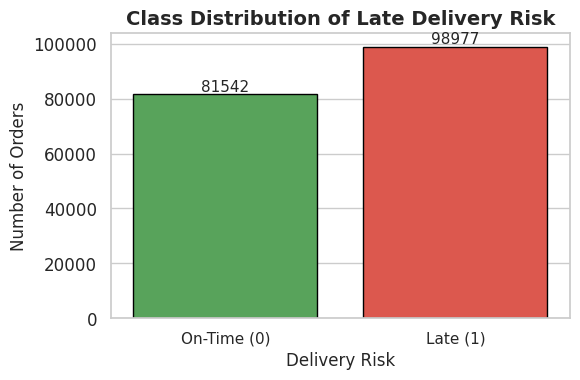

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# Use hue for colors, and disable the legend since it's redundant
ax = sns.countplot(x='Late_delivery_risk', hue='Late_delivery_risk',
                   data=df, palette=['#4CAF50', '#F44336'], legend=False, edgecolor='black')

# Add count labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, label_type='edge')

# Customize axes and title
ax.set_xticklabels(['On-Time (0)', 'Late (1)'], fontsize=11)
plt.title('Class Distribution of Late Delivery Risk', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Risk', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.tight_layout()
plt.show()

**Late Delivery Risk Analysis:**

The plot compares the count of orders that were **On-Time** (labeled '0') versus those classified as **Late** (labeled '1'), indicating the delivery risk status for the dataset.

* **Late Orders Dominate:** The vast majority of orders fall into the **Late (1)** category, totaling **98,977** orders.
* **On-Time Orders:** The **On-Time (0)** category accounts for **81,542** orders.
* **Imbalanced Classes:** The classes are **imbalanced**, with significantly more late orders than on-time orders. The number of late orders is approximately **21.4% higher** than the number of on-time orders ($98,977 - 81,542 = 17,435$ more late orders).

This distribution is critical for any subsequent analysis or machine learning model, as it suggests that late delivery is the **more frequent outcome** in the supply chain data.

---

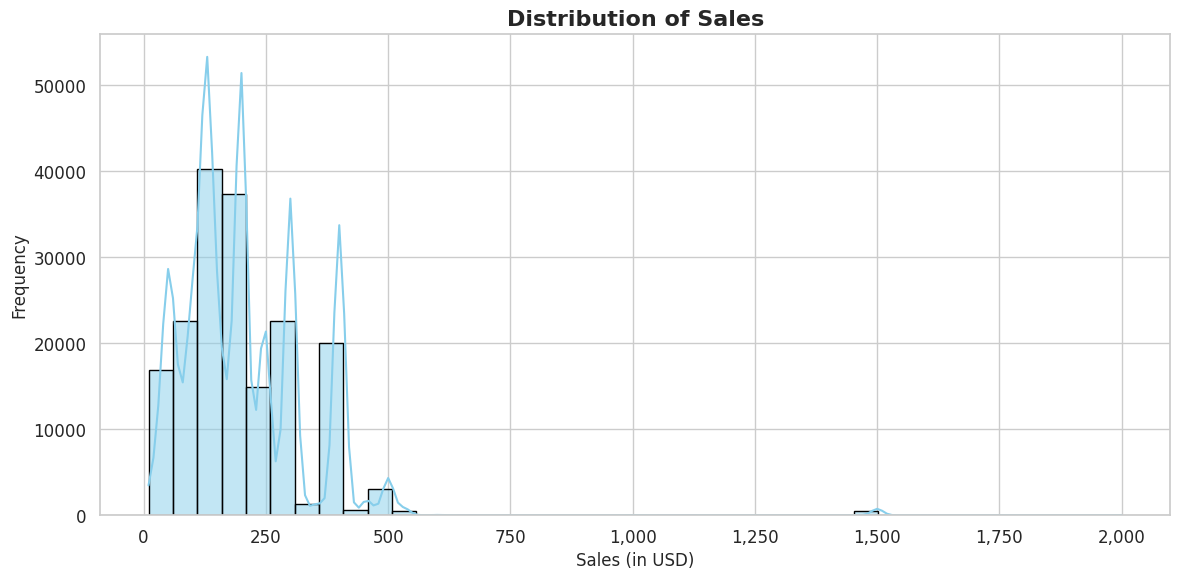

In [55]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Sales', bins=40, kde=True, color="skyblue", edgecolor="black")

# Format x-axis with commas
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title('Distribution of Sales', fontsize=16, fontweight='bold')
plt.xlabel('Sales (in USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

**Analysis of Sales Distribution**

The plot shows how often different sales amounts occur, focusing on the lower end of the sales spectrum.

* **High Frequency at Low Sales:** The distribution is heavily concentrated towards the lower sales values, indicating that the vast majority of transactions are for amounts **less than \$500**.
* **Multiple Modes (Peaks):** The data is **multimodal**, featuring several distinct peaks in frequency:
    * The largest peak is prominent around **\$100 to \$150**, with a frequency exceeding 50,000.
    * Other significant peaks occur near **\$200–\$250** and **\$350–\$450**.
* **Rapid Drop-off:** The frequency of transactions drops off dramatically after \$500. Sales amounts between **\$500 and \$1,500** are extremely rare, with the histogram bars near zero for this range.
* **Outlier/High-Value Transactions:** There is a tiny spike, indicating a very low frequency, of transactions occurring around **\$1,500**. This suggests that sales of this magnitude are rare, high-value outliers compared to the bulk of the transactions.
* **Overall Skewness:** The distribution is highly **right-skewed** (positively skewed), which is typical for sales data where many small transactions occur, and very few transactions occur at high dollar amounts.

---

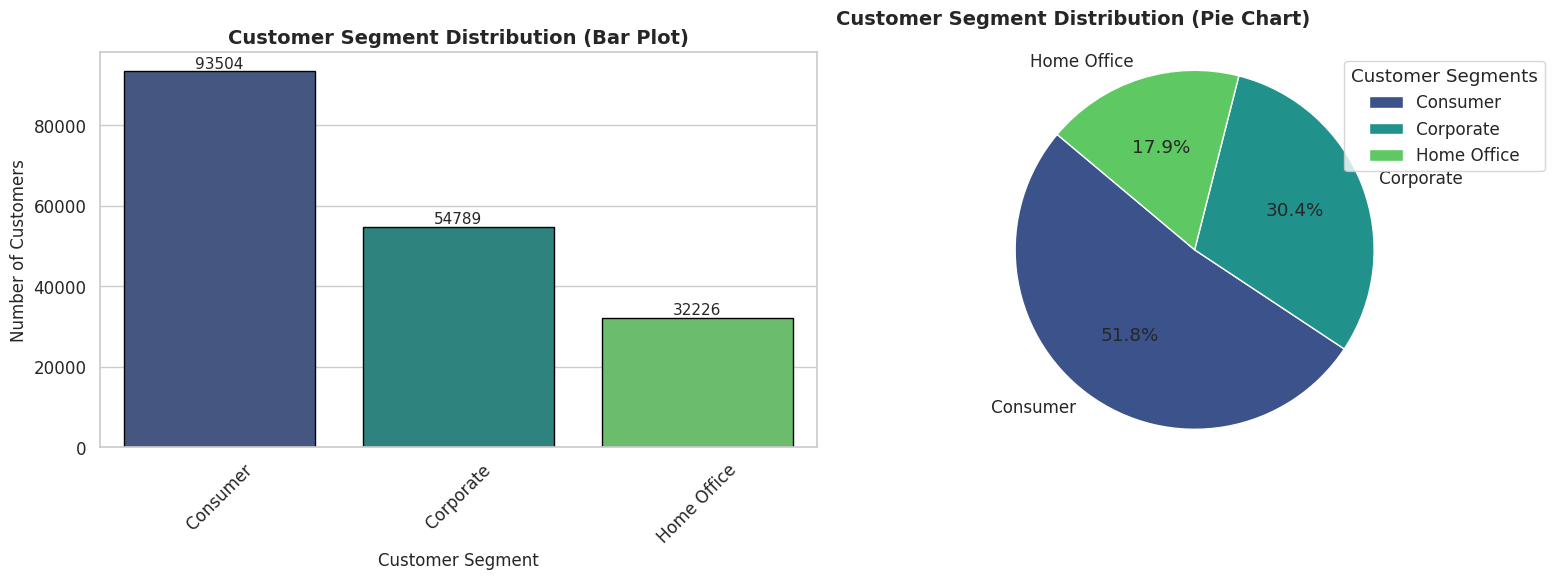

In [56]:
# Count of customers in each segment
customer_segment_counts = df['Customer Segment'].value_counts()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Plot ---
ax1 = axes[0]
sns.barplot(x=customer_segment_counts.index, y=customer_segment_counts.values,
            palette="viridis", edgecolor='black', ax=ax1)

# Add counts on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, label_type='edge')

ax1.set_title('Customer Segment Distribution (Bar Plot)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Customer Segment', fontsize=12)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.set_xticklabels(customer_segment_counts.index, rotation=45)

# --- Pie Chart ---
ax2 = axes[1]
ax2.pie(customer_segment_counts, labels=customer_segment_counts.index,
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(customer_segment_counts)))
ax2.set_title('Customer Segment Distribution (Pie Chart)', fontsize=14, fontweight='bold', loc='left', pad=20)
ax2.axis('equal')  # Equal aspect ratio ensures pie is circular
ax2.legend(customer_segment_counts.index, title='Customer Segments', loc='best')

plt.tight_layout()
plt.show()

**Customer Segment Analysis**

The visualization provides a comprehensive breakdown of the customer base across three distinct segments: **Consumer**, **Corporate**, and **Home Office**.

* The **Consumer** segment has the largest number of customers, totaling **93,504**, which accounts for over half of the entire customer base at **51.8%**.
* The **Corporate** segment is the second largest, with **54,789** customers, representing nearly one-third of the total customer count at **30.4%**.
* The **Home Office** segment is the smallest, accounting for **32,226** customers, which makes up the remaining **17.9%** of the customer base.

The **Consumer** segment represents over half of the entire customer base, making it the primary focus in terms of sheer numbers.This highlights the importance of focusing on accurate demand forecasting, inventory planning,   and on-time delivery for this segment, as it represents the majority of orders and significantly impacts overall supply chain performance.
The **Corporate** and **Home Office** segments together account for the remaining 48.3%.

---

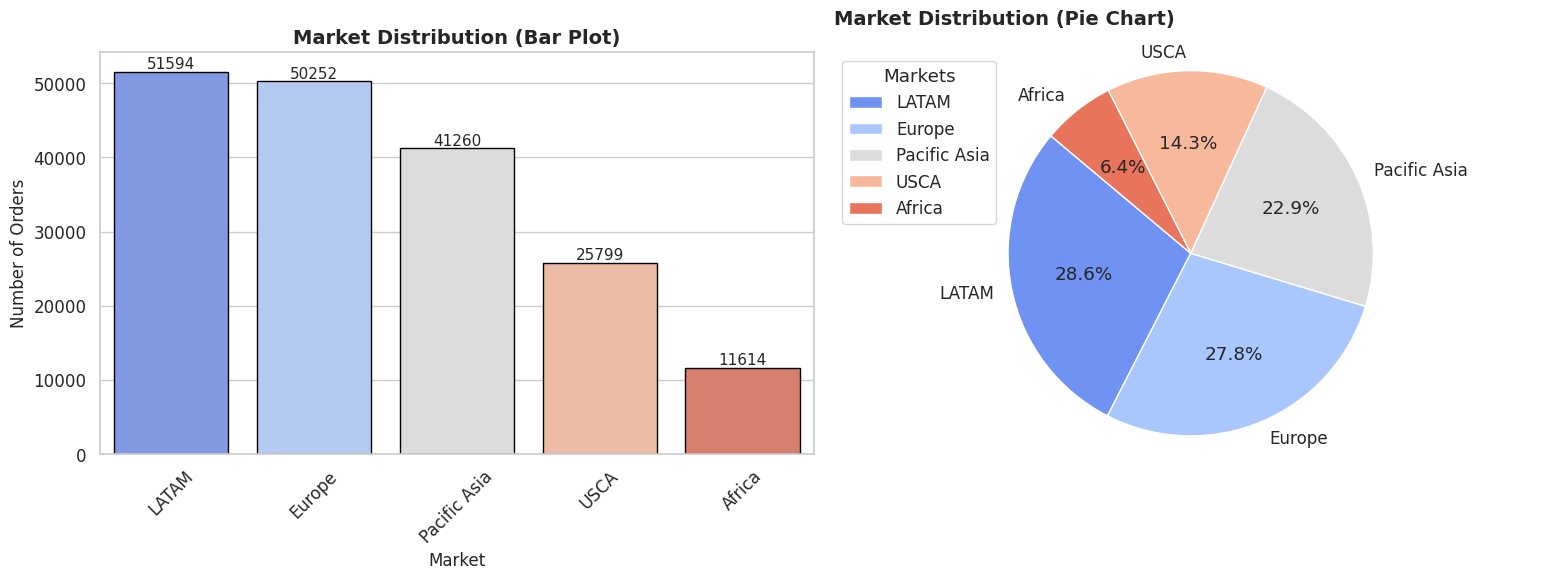

In [57]:
# Count of orders in each market
market_counts = df['Market'].value_counts()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Plot ---
ax1 = axes[0]
sns.barplot(x=market_counts.index, y=market_counts.values,
            palette="coolwarm", edgecolor='black', ax=ax1)

# Add counts on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', fontsize=11, label_type='edge')

ax1.set_title('Market Distribution (Bar Plot)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Market', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12)
ax1.set_xticklabels(market_counts.index, rotation=45)

# --- Pie Chart ---
ax2 = axes[1]
ax2.pie(market_counts, labels=market_counts.index,
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette("coolwarm", len(market_counts)))
ax2.set_title('Market Distribution (Pie Chart)', fontsize=14, fontweight='bold', loc='left', pad=20)
ax2.axis('equal')  # Equal aspect ratio ensures pie is circular
ax2.legend(market_counts.index, title='Markets', loc='best')

plt.tight_layout()
plt.show()

**Market Distribution Analysis**

The data clearly identifies **LATAM** (Latin America) and **Europe** as the dominant markets, both in terms of absolute order volume and percentage share.

* The **LATAM** region has the highest number of orders at **51,594**, securing the largest percentage of the total market at **28.6%**.
* **Europe** follows very closely, with **50,252** orders, representing **27.8%** of the market share.

Together, these two regions account for **56.4%** of all orders, making them the primary drivers of total volume. This highlights the critical importance of ensuring robust logistics networks, efficient warehousing, and low lead times in these regions to maximize operational efficiency and maintain customer satisfaction.

The remaining three regions account for the other segment of the market:

* **Pacific Asia** is a significant third market, with **41,260** orders, contributing **22.9%** to the total volume.
* **USCA** (United States and Canada) holds **25,799** orders, or **14.3%** of the share.
* **Africa** is the smallest market shown, with **11,614** orders, accounting for **6.4%** of the total.

The distinct differences in order volume across these markets suggest that supply chain strategies, such as inventory stocking levels and fulfillment priorities, should be tiered to reflect this distribution.

---

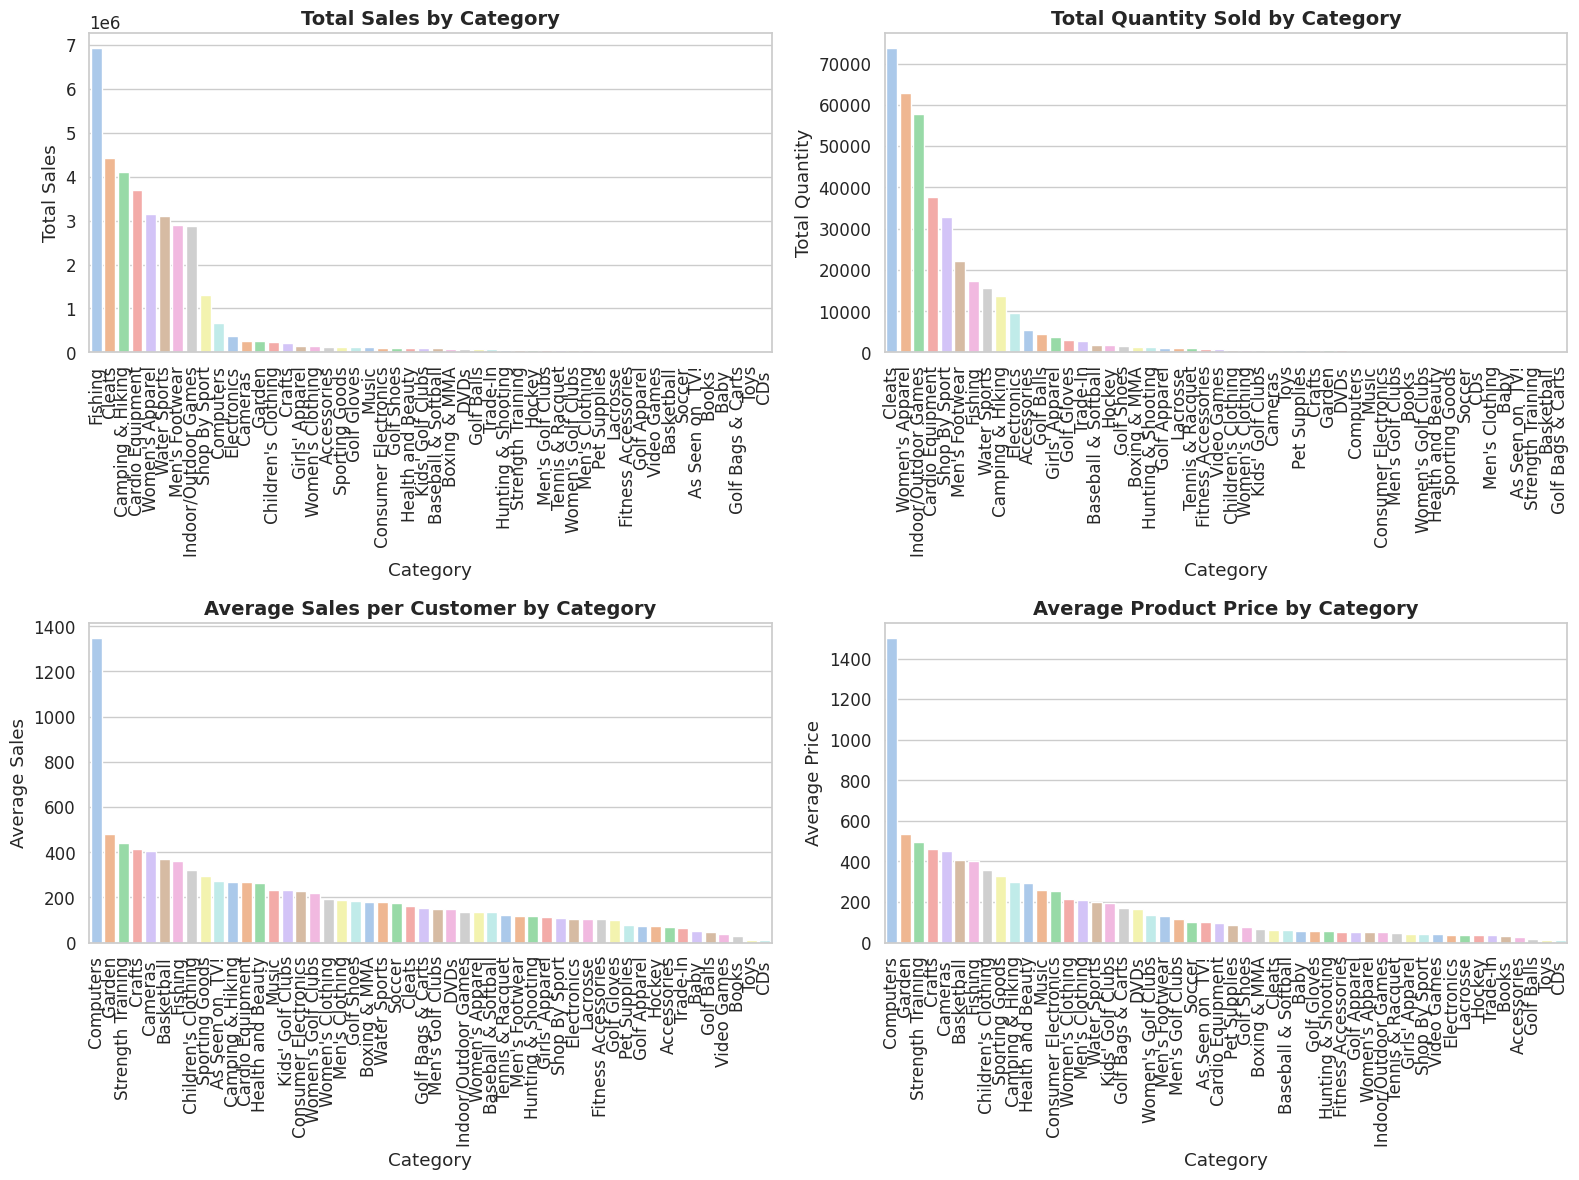

In [58]:
palette = sns.color_palette("pastel")

# Group by Category Name
Category = df.groupby('Category Name')

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Total Sales ---
total_sales = Category['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=total_sales.index, y=total_sales.values, palette=palette, ax=axes[0, 0])
axes[0, 0].set_title("Total Sales by Category", fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Total Sales")
axes[0, 0].tick_params(axis='x', rotation=90)

# --- Total Quantity ---
total_quantity = Category['Order Item Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=total_quantity.index, y=total_quantity.values, palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("Total Quantity Sold by Category", fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Total Quantity")
axes[0, 1].tick_params(axis='x', rotation=90)

# --- Average Sales per Customer ---
avg_sales = Category['Sales per customer'].mean().sort_values(ascending=False)
sns.barplot(x=avg_sales.index, y=avg_sales.values, palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("Average Sales per Customer by Category", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Category")
axes[1, 0].set_ylabel("Average Sales")
axes[1, 0].tick_params(axis='x', rotation=90)

# --- Average Product Price ---
avg_price = Category['Product Price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values, palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("Average Product Price by Category", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Category")
axes[1, 1].set_ylabel("Average Price")
axes[1, 1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

This set of four bar plots provides a comprehensive analysis of the **Category** performance.

1. Revenue and Volume Drivers (Total Sales and Quantity)

The top two charts, **Total Sales by Category** and **Total Quantity Sold by Category**, show a strong correlation, indicating that overall revenue is primarily driven by sales volume.

* **Dominance of Fishing:** The **Fishing** category is the clear leader in both metrics, recording the highest **Total Sales** and the highest **Total Quantity** sold. This signifies that Fishing products are the most frequently sold items by volume across the entire supply chain.
* **Next Tier Categories:** Following Fishing, categories like **Camping & Hiking**, **Water Sports**, and **Indoor/Outdoor Games** consistently form the next tier of high-volume and high-revenue generating products.
* **Low Performers:** Categories such as 'CDS', 'Videos', and 'Golf Bags & Carts' have the lowest contributions to both total sales and total quantity.

2. Value and Pricing Drivers (Average Sales and Price)

The bottom two charts, **Average Sales per Customer by Category** and **Average Product Price by Category**, highlight product categories that drive high value per transaction, independent of total volume. The rankings here are significantly different from the volume charts.

* **Highest Value Transactions:** The **Computers** category emerges as the leader in both **Average Sales per Customer** and **Average Product Price**. This indicates that while the total volume of Computers sold may be lower (as seen in the top charts), the high unit price of these items results in the highest average revenue generated per single customer transaction for that category.
* **Premium Categories:** Other categories with high average pricing and customer spend include **Strength Training**, **Basketball**, and **Children's Clothing**.
* **Volume vs. Value Discrepancy:** High-volume categories like **Fishing** and **Camping & Hiking** appear lower on these average value charts. This confirms a key insight: the success of the Fishing category is due to a **high number of transactions involving lower-priced items**, while the success of the Computers category is due to a **lower number of transactions involving very high-priced items**.

---

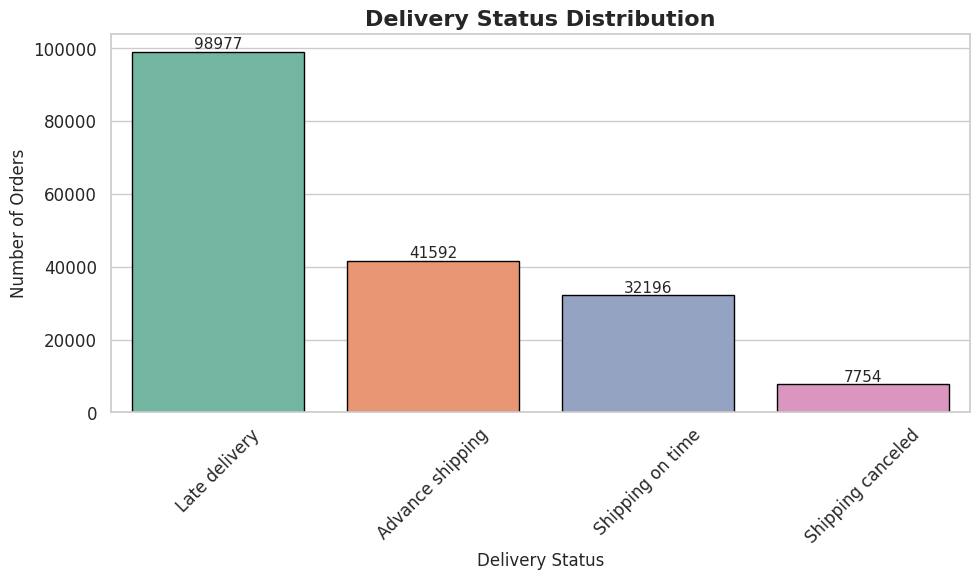

In [59]:
# Select column
delivery_status_data = df['Delivery Status']

# Summary statistics
delivery_status_summary = delivery_status_data.value_counts()

# Set style
palette = sns.color_palette("Set2")

# Plot
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Delivery Status',
                   order=delivery_status_summary.index, palette=palette, edgecolor='black')

# Add counts on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, label_type='edge')

# Titles and labels
plt.title('Delivery Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)

plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.tight_layout()
plt.show()

**Delivery Status Analysis**

The data separates orders into four distinct delivery categories, showing a clear imbalance in the frequency of each status.

* **Late Delivery Dominance:** The most frequent status is **Late delivery**, accounting for **98,977** orders. This is the single largest category by a significant margin, suggesting a major operational challenge in meeting delivery deadlines.
* **Advance Shipping:** The second most common status is **Advance shipping** (delivery ahead of schedule), with **41,592** orders.
* **Shipping On Time:** Orders that were **Shipping on time** (meeting the deadline exactly) total **32,196**.
* **Shipping Canceled:** The least frequent status is **Shipping canceled**, with only **7,754** orders.

---

<Figure size 1200x800 with 0 Axes>

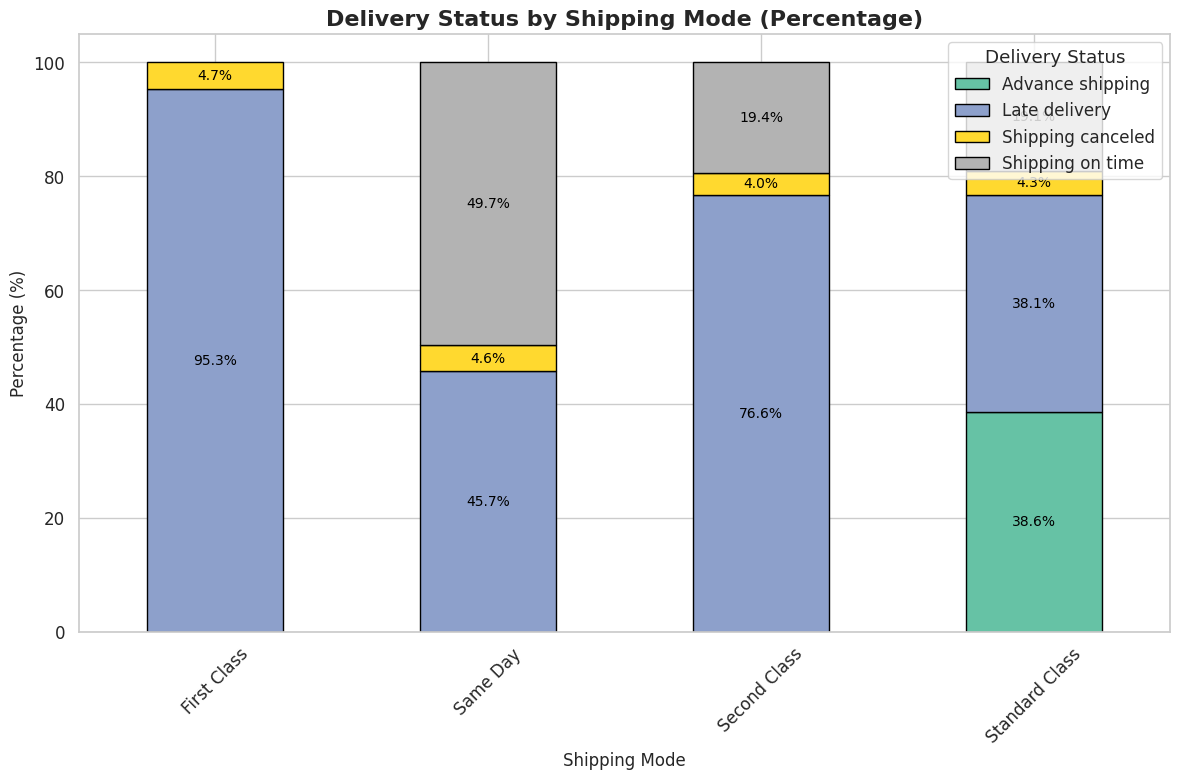

In [60]:
# Filter late deliveries (optional)
late_deliveries = df[df['Delivery Status'] == 'Late delivery']

# Select data
delivery_status_data = df['Delivery Status']
shipping_mode_data = df['Shipping Mode']

# Create cross-tabulation
cross_tab = pd.crosstab(shipping_mode_data, delivery_status_data)

# Calculate row percentages
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
plt.figure(figsize=(12, 8))
ax = cross_tab_percent.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black', figsize=(12,8))

plt.title('Delivery Status by Shipping Mode (Percentage)', fontsize=16, fontweight='bold')
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)

# Add percentage labels on top of each segment
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0:  # only label non-zero values
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontsize=10, color='black')

plt.legend(title='Delivery Status', loc='upper right')
plt.tight_layout()
plt.show()

**Delivery Status by Shipping Mode Analysis**

The analysis compares the proportion of four delivery outcomes (**Advance shipping**, **Late delivery**, **Shipping canceled**, and **Shipping on time**) across the four major shipping modes.

1. Delivery Status Dominance by Shipping Mode

The status that accounts for the largest percentage varies by shipping mode:

* **First Class:** Heavily dominated by **Late delivery** at **95.3%**.
* **Same Day:** The largest segment is **Shipping on time** at **49.7%**, meaning Late delivery (45.7%) is *not* the primary outcome.
* **Second Class:** Strongly dominated by **Late delivery** at **76.6%**.
* **Standard Class:** The largest segment is **Advance shipping** at **38.6%**, which is marginally higher than the Late delivery rate of **38.1%**.

2. Key Performance Insights

* **Highest Late Rate:** **First Class** is the least reliable, with over **95%** of orders resulting in late delivery.
* **Best Reliability:** The **Same Day** mode shows the best on-time performance, with its lowest **Late delivery** rate at **45.7%** and the highest **Shipping on time** rate at **49.7%**.
* **Most Orders Ahead of Schedule:** **Standard Class** has the highest percentage of **Advance shipping** at **38.6%**.
* **Highest Cancellation Rate:** **Same Day** shipping has the highest percentage of **Shipping canceled** orders at **4.6%**.

---

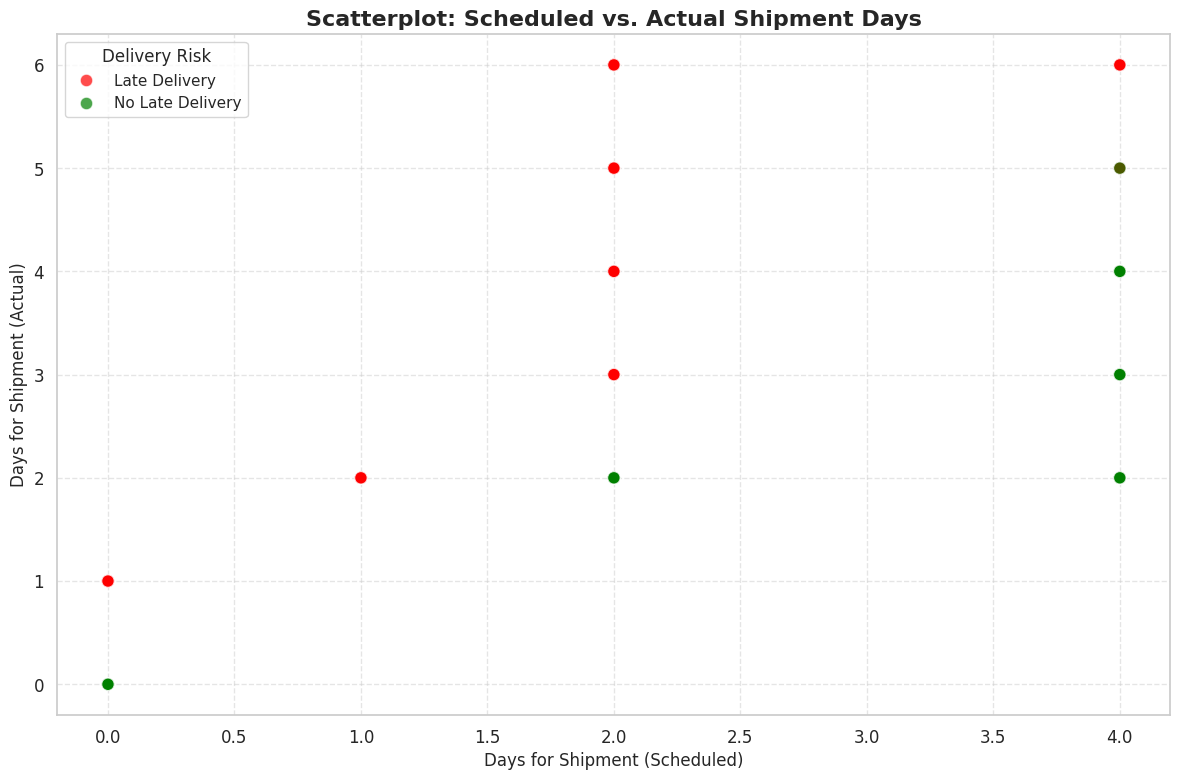

In [61]:
# Map Late_delivery_risk to descriptive labels
df['Late_delivery_risk'] = df['Late_delivery_risk'].map({0: 'No Late Delivery', 1: 'Late Delivery'})

# Color palette
palette = {'No Late Delivery': 'green', 'Late Delivery': 'red'}

# Set Seaborn style
sns.set_context("notebook", font_scale=1.1)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(x="Days for shipment (scheduled)", y="Days for shipping (real)",
    hue="Late_delivery_risk", data=df, palette=palette, s=80, alpha=0.7)

# Titles and labels
plt.title('Scatterplot: Scheduled vs. Actual Shipment Days', fontsize=16, fontweight='bold')
plt.xlabel('Days for Shipment (Scheduled)', fontsize=12)
plt.ylabel('Days for Shipment (Actual)', fontsize=12)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Delivery Risk', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

**Analysis of Delivery Risk**

The key to interpreting this plot is the conceptual line $Y=X$ (where Actual Days equals Scheduled Days).

The plot shows a **perfect classification of late delivery**: an order is classified as a **Late Delivery** (red point) if and only if the **Actual Days for Shipment** is **greater than** the **Days for Shipment (Scheduled)**. Conversely, an order is classified as **No Late Delivery** (green point) if the Actual Days for Shipment is **less than or equal to** the Scheduled Days for Shipment.

1. No Late Delivery (Green Points)

The green points, labeled **'No Late Delivery'**, consistently fall at or below the scheduled shipment time:

* **Ahead of Schedule:** For all scheduled day values greater than zero (1, 2, 3, and 4 days), the actual shipment time is **less than** the scheduled time. For example, when **4 days** are scheduled, the orders are delivered in 2, 3, or 4 actual days.
* **On Time:** The green points appear to define the **maximum acceptable actual shipping time** for that scheduled duration. For instance, an order scheduled for 4 days that takes exactly 4 days is classified as 'No Late Delivery'.

2. Late Delivery (Red Points)

The red points, labeled **'Late Delivery'**, occur when the actual shipment time **exceeds** the scheduled time:

* **Actual Exceeds Scheduled:** For every scheduled day value (1, 2, 3, and 4 days), the 'Late Delivery' points always plot **above** the 'No Late Delivery' points and significantly above the scheduled time.
    * An order scheduled for **2 days** that takes 3, 4, 5, or 6 days is marked as late.
    * An order scheduled for **4 days** that takes 5 or 6 days is marked as late.

---    

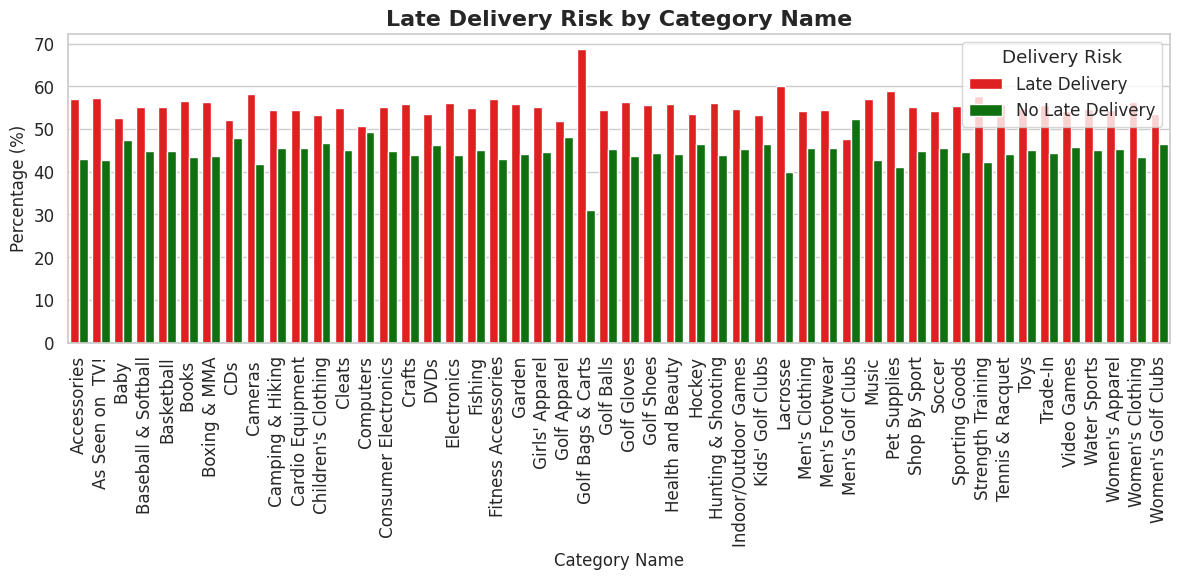

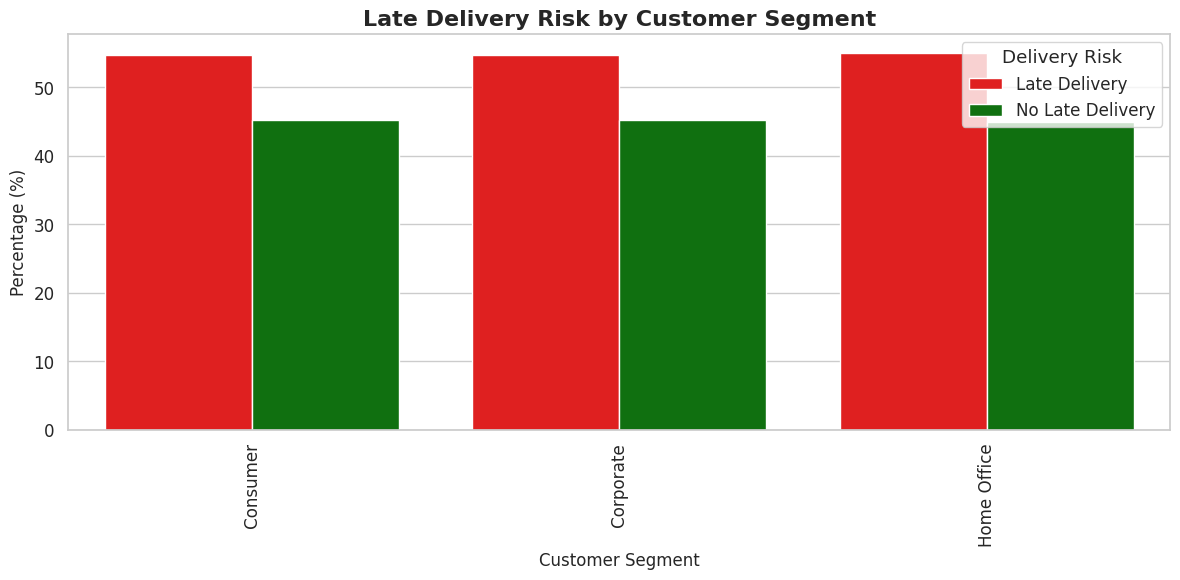

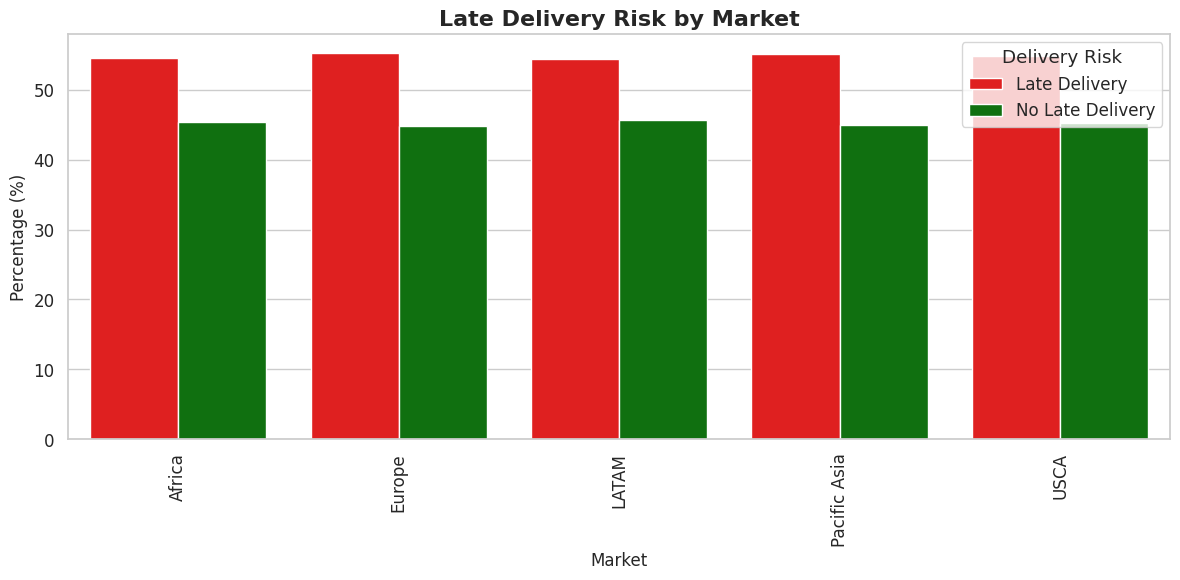

In [62]:
def plot_late_delivery_by_feature_sns(feature_name):
    # Create cross-tab and calculate percentages
    cross_tab = pd.crosstab(df[feature_name], df['Late_delivery_risk'])
    cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100

    # Convert to long format for seaborn
    data_long = cross_tab_percent.reset_index().melt(
        id_vars=feature_name,
        var_name='Delivery Risk',
        value_name='Percentage'
    )

    # Plot
    plt.figure(figsize=(12,6))
    sns.barplot(
        x=feature_name,
        y='Percentage',
        hue='Delivery Risk',
        data=data_long,
        palette={'No Late Delivery': 'green', 'Late Delivery': 'red'} # Changed keys to string labels
    )

    plt.title(f'Late Delivery Risk by {feature_name}', fontsize=16, fontweight='bold')
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xticks(rotation=90)
    plt.legend(title='Delivery Risk', loc='upper right')
    plt.tight_layout()
    plt.show()

# Example usage
plot_late_delivery_by_feature_sns('Category Name')
plot_late_delivery_by_feature_sns('Customer Segment')
plot_late_delivery_by_feature_sns('Market')

This analysis, spanning **Customer Segment**, **Market**, and **Product Category**, reveals a pervasive issue: **Late Delivery is the dominant outcome across the entire operation.**

The defining characteristic across the Customer Segment and Market dimensions is the near-uniformity of the late delivery risk, suggesting the cause is **systemic and internal**, rather than customer or geography-specific.

Systemic Late Delivery (The Consistent Majority) 🔴

* **Customer Segments:** The Late Delivery risk is virtually identical—approximately **54%**—for the **Consumer**, **Corporate**, and **Home Office** segments. The customer type has no observable impact on delivery success.
* **Markets:** Similarly, the Late Delivery percentage falls consistently between **53% and 55%** for all five markets (**Europe**, **LATAM**, **Pacific Asia**, **USCA**, and **Africa**). This strong consistency indicates that the challenges are not rooted in external, market-specific logistics.

Exceptions to the Rule (The Drivers of Variation) ⛳

The only dimension showing significant variation is **Product Category**, which helps isolate areas for targeted improvement:

* **Highest Risk Categories:** The primary risk clusters around **Golf-related products**, where late delivery risk spikes dramatically. **Golf Bags & Carts** are the clear outlier, with a late delivery rate approaching **70%**. Other Golf clubs (Men's, Women's, and Kids') also show risk rates well over 60%.
* **Lowest Risk Categories:** Categories with relatively lower risk (closest to a 50/50 split) include smaller, non-physical, or easily managed items like **CDs**, **DVDs**, and **Music**.

---

In [63]:
import plotly.express as px

# Aggregate orders by city (latitude & longitude)
orders_geo = df.groupby(['Customer City', 'Latitude', 'Longitude']).size().reset_index(name='num_orders')

# Create an interactive world map
fig = px.scatter_geo(orders_geo, lat='Latitude',
    lon='Longitude', hover_name='Customer City',
    size='num_orders',          # bubble size proportional to number of orders
    color='num_orders',         # color scale for number of orders
    color_continuous_scale='Viridis', projection='natural earth', title='Worldwide Orders by City')

fig.update_layout(geo=dict(showland=True, landcolor="lightgray"), title_x=0.5)

fig.show()

## **Preprocessing**

### **Handling Missing Values**

In [64]:
num_cols = df.select_dtypes(include=['number']).shape[1] # Count numerical columns (int, float types)
cat_cols = df.select_dtypes(include=['object', 'category']).shape[1] # Count categorical columns (object, category types)

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numerical columns: 20
Categorical columns: 20


In [65]:
df.isna().sum()  # Count the number of missing (NaN) values in each column

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


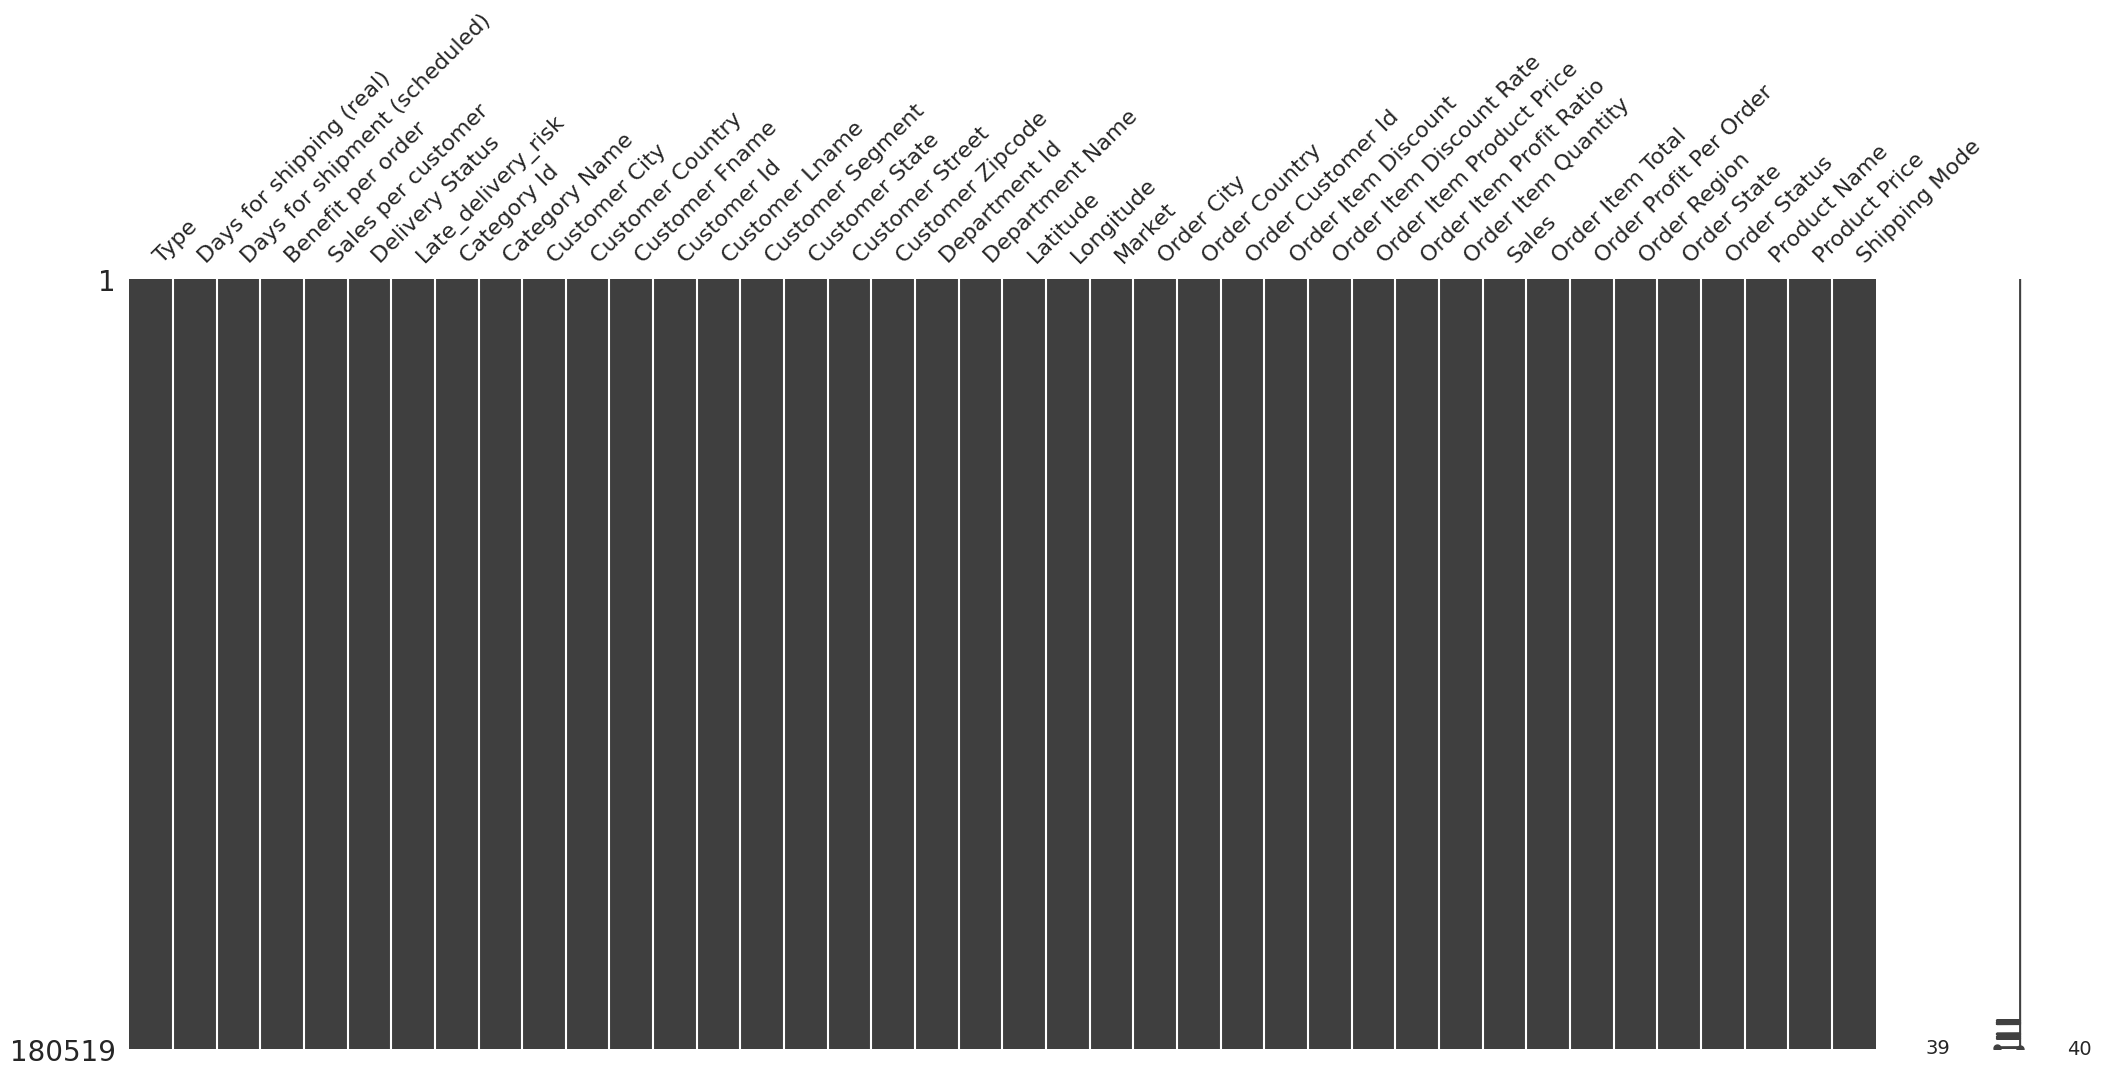

In [66]:
import missingno as msno
msno.matrix(df);

- Almost all columns have no missing values, which shows the dataset is clean.
- The columns with missing values are:
  * Customer Lname (8 missing)
  * Customer Zipcode (3 missing)
  * Order Zipcode (155,679 missing)
  * Product Description (180,519 missing)

These columns are either not relevant for predicting Late Delivery Risk (e.g., names, zip codes, product descriptions) or contain too many missing values.
Therefore, we will drop them from the dataset to simplify analysis and modeling.

### **Dropping Unnecessary Columns**

In [67]:
df = df.drop([
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Product Description',
    'Product Image',
    'Product Status',
    'Order Zipcode'
], axis=1, errors='ignore')

In [68]:
id_cols = [
    'Order Id', 'Customer Id', 'Order Item Id', 'Order Item Cardprod Id',
    'Product Card Id'
]
df = df.drop(columns=id_cols, errors='ignore')

In [69]:
# Drop leakage columns
leakage_cols = [
    'Days for shipping (real)',   # post-delivery info
    'shipping date (DateOrders)'
]

df = df.drop(columns=leakage_cols, errors='ignore')

print("Remaining columns after leakage removal:", df.columns)

Remaining columns after leakage removal: Index(['Type', 'Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Id', 'Category Name', 'Customer City', 'Customer Country',
       'Customer Segment', 'Customer State', 'Department Id',
       'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Shipping Mode'],
      dtype='object')


### **Feature Engineering**

In [91]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("APL_Logistics.csv", encoding='latin1')


# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("Duplicates Removed")
print("Updated Columns:")
print(df.columns.tolist())


# =========================
#  HANDLE MISSING VALUES
# =========================

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical missing values with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values Handled")


# =========================
# REMOVE DATA LEAKAGE
# =========================

# Remove columns that directly reveal outcome
leakage_cols = [
    'Delivery_Status',
    'Days_for_shipping_(real)'
]

existing_leakage_cols = [col for col in leakage_cols if col in df.columns]

# Re-derive Late_delivery_risk from Delivery_Status before it's potentially dropped
# This ensures Late_delivery_risk is always correctly numerical (0 or 1)
if 'Delivery_Status' in df.columns:
    df['Late_delivery_risk'] = df['Delivery_Status'].map({
        'Late delivery': 1,
        'Shipping on time': 0,
        'Advance shipping': 0,
        'Shipping canceled': 0
    })
    print("Late_delivery_risk re-derived from Delivery_Status.")
else:
    # Fallback if Delivery_Status was already dropped or renamed, and Late_delivery_risk might be string-typed.
    # This part handles cases where Late_delivery_risk might still be string-typed from previous viz.
    if df['Late_delivery_risk'].dtype == 'object':
        df['Late_delivery_risk'] = df['Late_delivery_risk'].map({
            'No Late Delivery': 0,
            'Late Delivery': 1
        })
        print("Late_delivery_risk converted from string object to numerical.")
    else:
        print("Late_delivery_risk already numerical or no Delivery_Status to re-derive from.")

df.drop(columns=existing_leakage_cols, inplace=True)

print("Leakage Columns Removed")

# =========================
# FEATURE ENGINEERING
# =========================

# ------------------------------------------------
# A. SHIPPING PRESSURE INDEX
# ------------------------------------------------
# Formula:
# Quantity / Scheduled Shipping Days

df['Shipping_Pressure_Index'] = (
    df['Order_Item_Quantity'] /
    (df['Days_for_shipment_(scheduled)'] + 1)
)

print("Shipping Pressure Index Created")


# ------------------------------------------------
# B. DELIVERY GAP
# ------------------------------------------------
# Actual - Scheduled Shipping Days

# This feature should not be created if 'Days_for_shipping_(real)' was considered a leakage column and dropped.
# Assuming 'Days_for_shipping_(real)' is now removed or handled before this point.
if 'Days_for_shipping_(real)' in df.columns:

    df['Delivery_Gap'] = (
        df['Days_for_shipping_(real)'] -
        df['Days_for_shipment_(scheduled)']
    )

print("Delivery Gap Created")


# ------------------------------------------------
# C. ORDER COMPLEXITY SCORE
# ------------------------------------------------

# Higher quantity + higher price = higher complexity

df['Order_Complexity_Score'] = (
    df['Order_Item_Quantity'] *
    df['Order_Item_Product_Price']
)

print("Order Complexity Score Created")


# ------------------------------------------------
# D. PROFIT MARGIN
# ------------------------------------------------

df['Profit_Margin'] = (
    df['Order_Profit_Per_Order'] /
    (df['Sales'] + 1)
)

print("Profit Margin Created")


# ------------------------------------------------
# E. DISCOUNT IMPACT SCORE
# ------------------------------------------------

df['Discount_Impact'] = (
    df['Order_Item_Discount_Rate'] *
    df['Sales']
)

print("Discount Impact Feature Created")


# ------------------------------------------------
# F. EXPRESS SHIPPING FLAG
# ------------------------------------------------

df['Express_Shipping_Flag'] = np.where(
    df['Shipping_Mode'].str.lower().isin([
        'first class',
        'same day',
        'standard class'
        'second class'
    ]),
    1,
    0
)

print("Express Shipping Flag Created")


# ------------------------------------------------
# G. HIGH VALUE ORDER FLAG
# ------------------------------------------------

sales_threshold = df['Sales'].quantile(0.75)

df['High_Value_Order'] = np.where(
    df['Sales'] >= sales_threshold,
    1,
    0
)

print("High Value Order Flag Created")


# ------------------------------------------------
# H. BULK ORDER FLAG
# ------------------------------------------------

quantity_threshold = df['Order_Item_Quantity'].quantile(0.75)

df['Bulk_Order_Flag'] = np.where(
    df['Order_Item_Quantity'] >= quantity_threshold,
    1,
    0
)

print("Bulk Order Flag Created")


# ------------------------------------------------
# I. REGION RISK SCORE
# ------------------------------------------------

# Average historical late delivery risk by region

if 'Order_Region' in df.columns:

    region_risk = (
        df.groupby('Order_Region')['Late_delivery_risk']
        .mean()
        .to_dict()
    )

    df['Region_Risk_Score'] = (
        df['Order_Region']
        .map(region_risk)
    )

print("Region Risk Score Created")


# ------------------------------------------------
# J. SHIPPING MODE RISK SCORE
# ------------------------------------------------

mode_risk = (
    df.groupby('Shipping_Mode')['Late_delivery_risk']
    .mean()
    .to_dict()
)

df['Shipping_Mode_Risk'] = (
    df['Shipping_Mode']
    .map(mode_risk)
)

print("Shipping Mode Risk Score Created")


# ------------------------------------------------
# K. CUSTOMER SEGMENT RISK
# ------------------------------------------------

segment_risk = (
    df.groupby('Customer_Segment')['Late_delivery_risk']
    .mean()
    .to_dict()
)

df['Customer_Segment_Risk'] = (
    df['Customer_Segment']
    .map(segment_risk)
)

print("Customer Segment Risk Created")


# ------------------------------------------------
# L. PRICE PER UNIT
# ------------------------------------------------

df['Price_Per_Unit'] = (
    df['Order_Item_Total'] /
    (df['Order_Item_Quantity'] + 1)
)

print("Price Per Unit Feature Created")


# ------------------------------------------------
# M. SALES TO PROFIT RATIO
# ------------------------------------------------

denominator_sales_profit = df['Order_Profit_Per_Order'] + 1
# Replace 0s in denominator with a small epsilon to avoid division by zero
epsilon = 1e-6
denominator_sales_profit = np.where(denominator_sales_profit == 0, epsilon, denominator_sales_profit)

df['Sales_Profit_Ratio'] = df['Sales'] / denominator_sales_profit

print("Sales Profit Ratio Created")


# ------------------------------------------------
# N. GEO LOCATION FEATURE
# ------------------------------------------------

# Combined geo coordinates

df['Geo_Location'] = (
    df['Latitude'].astype(str) + "_" +
    df['Longitude'].astype(str)
)

print("Geo Location Feature Created")


# =========================
# ENCODE CATEGORICAL VARIABLES
# =========================

# Label Encoding for high-cardinality features

high_cardinality_cols = [
    'Customer_City',
    'Customer_Country',
    'Order_City',
    'Order_Country',
    'Product_Name',
    'Category_Name'
]

le = LabelEncoder()

for col in high_cardinality_cols:

    if col in df.columns:

        df[col] = le.fit_transform(df[col].astype(str))

print("High Cardinality Features Encoded")


# =========================
# ONE-HOT ENCODING
# =========================

one_hot_cols = [
    'Shipping_Mode',
    'Customer_Segment',
    'Market',
    'Order_Region',
    'Order_Status',
    'Type'
]

existing_one_hot_cols = [
    col for col in one_hot_cols if col in df.columns
]

df = pd.get_dummies(
    df,
    columns=existing_one_hot_cols,
    drop_first=True
)

print("One-Hot Encoding Completed")


# =========================
#  OUTLIER HANDLING
# =========================

# Capping extreme values using IQR

outlier_cols = [
    'Sales',
    'Order_Item_Quantity',
    'Order_Item_Product_Price',
    'Benefit_per_order'
]

for col in outlier_cols:

    if col in df.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] > upper, upper, df[col])
        df[col] = np.where(df[col] < lower, lower, df[col])

print("Outliers Handled")


# =========================
#  FINAL FEATURE SELECTION
# =========================

# Remove unnecessary columns

drop_cols = [
    'Customer_Fname',
    'Customer_Lname',
    'Customer_Street',
    'Customer_Zipcode',
    'Geo_Location'
]

existing_drop_cols = [
    col for col in drop_cols if col in df.columns
]

df.drop(columns=existing_drop_cols, inplace=True)

print("Unnecessary Columns Removed")


# =========================
#  CHECK FINAL DATASET
# =========================

print("\nFinal Dataset Shape :", df.shape)

print("\nFinal Features:")
print(df.columns.tolist())

df.head()

Duplicates Removed
Updated Columns:
['Type', 'Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)', 'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status', 'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Fname', 'Customer_Id', 'Customer_Lname', 'Customer_Segment', 'Customer_State', 'Customer_Street', 'Customer_Zipcode', 'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market', 'Order_City', 'Order_Country', 'Order_Customer_Id', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Product_Price', 'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Sales', 'Order_Item_Total', 'Order_Profit_Per_Order', 'Order_Region', 'Order_State', 'Order_Status', 'Product_Name', 'Product_Price', 'Shipping_Mode']
Missing Values Handled
Late_delivery_risk re-derived from Delivery_Status.
Leakage Columns Removed
Shipping Pressure Index Created
Delivery Gap Created
Order Complexity Score Created
Profit Margin Created
Disc

,Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Category_Name,Customer_City,Customer_Country,Customer_Id,Customer_State,Department_Id,Department_Name,Latitude,Longitude,Order_City,Order_Country,Order_Customer_Id,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Order_State,Product_Name,Product_Price,Shipping_Pressure_Index,Order_Complexity_Score,Profit_Margin,Discount_Impact,Express_Shipping_Flag,High_Value_Order,Bulk_Order_Flag,Region_Risk_Score,Shipping_Mode_Risk,Customer_Segment_Risk,Price_Per_Unit,Sales_Profit_Ratio,Shipping_Mode_Same Day,Shipping_Mode_Second Class,Shipping_Mode_Standard Class,Customer_Segment_Corporate,Customer_Segment_Home Office,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,Order_Region_Caribbean,Order_Region_Central Africa,Order_Region_Central America,Order_Region_Central Asia,Order_Region_East Africa,Order_Region_East of USA,Order_Region_Eastern Asia,Order_Region_Eastern Europe,Order_Region_North Africa,Order_Region_Northern Europe,Order_Region_Oceania,Order_Region_South America,Order_Region_South Asia,Order_Region_South of USA,Order_Region_Southeast Asia,Order_Region_Southern Africa,Order_Region_Southern Europe,Order_Region_US Center,Order_Region_West Africa,Order_Region_West Asia,Order_Region_West of USA,Order_Region_Western Europe,Order_Status_CLOSED,Order_Status_COMPLETE,Order_Status_ON_HOLD,Order_Status_PAYMENT_REVIEW,Order_Status_PENDING,Order_Status_PENDING_PAYMENT,Order_Status_PROCESSING,Order_Status_SUSPECTED_FRAUD,Type_DEBIT,Type_PAYMENT,Type_TRANSFER
0,4,151.50,472.45,1,9,10,61,0,1,TX,3,Footwear,25.953648,-97.507683,2181,69,1,27.50,0.06,99.99,0.34,5.0,499.95,472.45,159.69,Maharashtra,61,99.99,1.0,499.95,0.318774,29.9970,0,1,1,0.562670,0.380717,0.548084,78.741667,3.111270,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1,4,48.71,167.96,0,29,38,276,0,2,CO,5,Golf,38.375595,-104.726021,2832,66,2,31.99,0.16,39.99,0.29,5.0,199.95,167.96,48.71,Cortés,102,39.99,1.0,199.95,0.242399,31.9920,0,0,1,0.547546,0.380717,0.548084,27.993333,4.022330,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
2,4,87.36,181.99,0,48,46,276,0,2,CO,7,Fan Shop,38.375595,-104.726021,2832,66,2,18.00,0.09,199.99,0.48,1.0,199.99,181.99,87.36,Cortés,70,199.99,0.2,199.99,0.434648,17.9991,0,0,0,0.547546,0.380717,0.548084,90.995000,2.263354,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
3,4,-41.89,175.99,1,48,46,276,0,2,CO,7,Fan Shop,38.375595,-104.726021,2256,48,2,24.00,0.12,199.99,-0.24,1.0,199.99,175.99,-41.89,Nueva York,70,199.99,0.2,199.99,-0.208418,23.9988,0,0,0,0.556616,0.380717,0.548084,87.995000,-4.890927,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
4,4,10.00,40.00,1,24,47,276,0,2,CO,5,Golf,38.375595,-104.726021,2256,48,2,10.00,0.20,50.00,0.25,1.0,50.00,40.00,10.00,Nueva York,59,50.00,0.2,50.00,0.196078,10.0000,0,0,0,0.556616,0.380717,0.548084,20.000000,4.545455,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False

In [71]:
df.head()

,Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Late_delivery_risk,Category_Id,Category_Name,Customer_City,Customer_Country,Customer_State,Department_Id,Department_Name,Latitude,Longitude,Order_City,Order_Country,Order_Customer_Id,Order_Item_Discount,Order_Item_Discount_Rate,Order_Item_Product_Price,Order_Item_Profit_Ratio,Order_Item_Quantity,Sales,Order_Item_Total,Order_Profit_Per_Order,Order_State,Product_Name,Product_Price,Shipping_Pressure_Index,Order_Complexity_Score,Profit_Margin,Discount_Impact,Express_Shipping_Flag,High_Value_Order,Bulk_Order_Flag,Region_Risk_Score,Shipping_Mode_Risk,Customer_Segment_Risk,Price_Per_Unit,Sales_Profit_Ratio,Shipping_Mode_Same Day,Shipping_Mode_Second Class,Shipping_Mode_Standard Class,Customer_Segment_Corporate,Customer_Segment_Home Office,Market_Europe,Market_LATAM,Market_Pacific Asia,Market_USCA,Order_Region_Caribbean,Order_Region_Central Africa,Order_Region_Central America,Order_Region_Central Asia,Order_Region_East Africa,Order_Region_East of USA,Order_Region_Eastern Asia,Order_Region_Eastern Europe,Order_Region_North Africa,Order_Region_Northern Europe,Order_Region_Oceania,Order_Region_South America,Order_Region_South Asia,Order_Region_South of USA,Order_Region_Southeast Asia,Order_Region_Southern Africa,Order_Region_Southern Europe,Order_Region_US Center,Order_Region_West Africa,Order_Region_West Asia,Order_Region_West of USA,Order_Region_Western Europe,Order_Status_CLOSED,Order_Status_COMPLETE,Order_Status_ON_HOLD,Order_Status_PAYMENT_REVIEW,Order_Status_PENDING,Order_Status_PENDING_PAYMENT,Order_Status_PROCESSING,Order_Status_SUSPECTED_FRAUD,Type_DEBIT,Type_PAYMENT,Type_TRANSFER
0,4,151.50,472.45,1,9,10,61,0,TX,3,Footwear,25.953648,-97.507683,2181,69,1,27.50,0.06,99.99,0.34,5.0,499.95,472.45,159.69,Maharashtra,61,99.99,1.0,499.95,0.318774,29.9970,0,1,1,0.562670,0.380717,0.548084,78.741667,3.111270,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
1,4,48.71,167.96,0,29,38,276,0,CO,5,Golf,38.375595,-104.726021,2832,66,2,31.99,0.16,39.99,0.29,5.0,199.95,167.96,48.71,Cortés,102,39.99,1.0,199.95,0.242399,31.9920,0,0,1,0.547546,0.380717,0.548084,27.993333,4.022330,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
2,4,87.36,181.99,0,48,46,276,0,CO,7,Fan Shop,38.375595,-104.726021,2832,66,2,18.00,0.09,199.99,0.48,1.0,199.99,181.99,87.36,Cortés,70,199.99,0.2,199.99,0.434648,17.9991,0,0,0,0.547546,0.380717,0.548084,90.995000,2.263354,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
3,4,-41.89,175.99,1,48,46,276,0,CO,7,Fan Shop,38.375595,-104.726021,2256,48,2,24.00,0.12,199.99,-0.24,1.0,199.99,175.99,-41.89,Nueva York,70,199.99,0.2,199.99,-0.208418,23.9988,0,0,0,0.556616,0.380717,0.548084,87.995000,-4.890927,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False
4,4,10.00,40.00,1,24,47,276,0,CO,5,Golf,38.375595,-104.726021,2256,48,2,10.00,0.20,50.00,0.25,1.0,50.00,40.00,10.00,Nueva York,59,50.00,0.2,50.00,0.196078,10.0000,0,0,0,0.556616,0.380717,0.548084,20.000000,4.545455,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,Tru

### **Encoding**

In [72]:
df['Late_delivery_risk'].unique()

array([1, 0])

In [73]:
# The 'Late_delivery_risk' column was converted to string labels for visualization.
# We need to convert it back to numerical (0 and 1) for model training.
# This mapping is already handled in cell TezMWtbD0k9r to ensure Late_delivery_risk is numerical.
# The following lines are commented out to prevent re-mapping numerical values to NaN.
# df['Late_delivery_risk'] = df['Late_delivery_risk'].map({
#     'No Late Delivery': 0,
#     'Late Delivery': 1})

# Verify the unique values in the target column to confirm its numerical nature
print("Unique values in Late_delivery_risk:", df['Late_delivery_risk'].unique())

# Verify mapping
df[['Late_delivery_risk']].head()

Unique values in Late_delivery_risk: [1 0]


,Late_delivery_risk
0,1
1,0
2,0
3,1
4,1


In [74]:
# Column names that were not explicitly encoded by the main preprocessing cell (TezMWtbD0k9r)
# but are still categorical and could benefit from Label Encoding.
columns_to_encode = [
    'Customer_State',
    'Department_Name',
    'Order_State'
]

# Initialize LabelEncoder
le = LabelEncoder()

# Encode the columns that are still present and of object type
for col in columns_to_encode:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"Column '{col}' label encoded.")
    elif col not in df.columns:
        print(f"Column '{col}' not found in DataFrame and was skipped.")
    else:
        print(f"Column '{col}' already encoded or is not of object type and was skipped.")

# Verify encoding for the columns that were actually processed in this cell
# Only display head if there are columns to show
if columns_to_encode:
    print("\nVerifying encoding:")
    # Filter for columns that were successfully encoded and are still in df
    encoded_and_present_cols = [col for col in columns_to_encode if col in df.columns and df[col].dtype != 'object']
    if encoded_and_present_cols:
        print(df[encoded_and_present_cols].head())
    else:
        print("No new columns were label encoded in this step or they are not in the DataFrame anymore.")
else:
    print("No columns were specified for encoding in this cell.")

Column 'Customer_State' label encoded.
Column 'Department_Name' label encoded.
Column 'Order_State' label encoded.

Verifying encoding:
   Customer_State  Department_Name  Order_State
0              40                5          610
1               6                6          260
2               6                3          260
3               6                3          741
4               6                6          741


### **Feature-Target Separation**

In [96]:
import numpy as np
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Define target columns
target_cols = ['Late_delivery_risk']

# Define features
feature_cols = [col for col in df.columns if col not in target_cols]

# Fill any remaining NaNs in the target variable with 0 as requested
df['Late_delivery_risk'].fillna(0, inplace=True)

X = df[feature_cols]                        # Features
y_late_risk = df['Late_delivery_risk']      # Binary target

# Handle infinite values in X by replacing them with NaN and then imputing with the median
# This step ensures that no infinite values are passed to the model training.
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# --- Ensure all columns in X are numeric ---
# Identify non-numeric columns in X
non_numeric_cols = X.select_dtypes(include=['object', 'category']).columns

if not non_numeric_cols.empty:
    print(f"Warning: Non-numeric columns found in X: {list(non_numeric_cols)}. Attempting to convert...")
    for col in non_numeric_cols:
        # Convert to numeric, coercing errors to NaN
        X[col] = pd.to_numeric(X[col], errors='coerce')
        print(f"Column '{col}' converted to numeric. NaN values introduced for unconvertible strings.")

# Impute any NaN values (including those introduced by conversion of non-numeric data)
for col in X.columns:
    if X[col].isnull().any():
        # For numerical columns, use median imputation
        if pd.api.types.is_numeric_dtype(X[col]):
            median_val = X[col].median()
            if pd.isna(median_val): # Check if median itself is NaN (i.e., column is all NaNs)
                # If median is NaN, it means the entire column is NaN after coercion.
                # Fill with 0 or a sensible default in this case.
                X[col].fillna(0, inplace=True)
                print(f"    -> Column '{col}' became all NaNs after coercion; filled with 0.")
            else:
                X[col].fillna(median_val, inplace=True)
                print(f"    -> Column '{col}' NaNs filled with median ({median_val}).")
        # For any remaining non-numeric (shouldn't happen after to_numeric) fill with mode or drop
        else:
            print(f"Warning: Column '{col}' is still non-numeric with NaNs after conversion. Filling with mode/0.")
            X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 0, inplace=True)

# --- Added: Final check to force all columns to float type ---
# This will raise an error if any column still contains non-convertible strings
# It's a defensive step to ensure all columns are numeric before model training
try:
    X = X.astype(float)
    print("All feature columns successfully converted to float.")
except ValueError as e:
    print(f"Critical Error: Failed to convert all features to float. Encountered: {e}")
    print("Please inspect X for non-numeric values after preprocessing.")
    raise # Allow the original ValueError to surface if it's still an issue

print("Features shape:", X.shape)
print("Late_delivery_risk shape:", y_late_risk.shape)

Column 'Customer_State' converted to numeric. NaN values introduced for unconvertible strings.
Column 'Department_Name' converted to numeric. NaN values introduced for unconvertible strings.
Column 'Order_State' converted to numeric. NaN values introduced for unconvertible strings.
All feature columns successfully converted to float.
Features shape: (180519, 81)
Late_delivery_risk shape: (180519,)


## **Prediction Model**

In [76]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Fits the given classifier, makes predictions, prints evaluation metrics,
    plots confusion matrix and ROC curve (if binary), and returns metrics & predictions.

    Returns a dictionary with all relevant metrics and y_pred.
    """

    # Fit the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='binary' if len(np.unique(y_test))==2 else 'macro')
    f1 = f1_score(y_test, y_pred, average='binary' if len(np.unique(y_test))==2 else 'macro')
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    # Print metrics
    print(f"=== {model_name} Evaluation ===")
    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Recall: {recall*100:.2f}%")
    print(f"F1 Score: {f1*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC-AUC curve (only for binary classification)
    auc_score = None
    if len(np.unique(y_test)) == 2:
        y_prob = model.predict_proba(X_test)[:,1]
        auc_score = roc_auc_score(y_test, y_prob)
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6,4))
        plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}', color='darkorange', linewidth=2)
        plt.plot([0,1], [0,1], 'k--', linewidth=1)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} - ROC Curve')
        plt.legend(loc='lower right')
        plt.show()
        print(f"ROC-AUC Score: {auc_score:.2f}")

    # Save metrics in a dictionary
    metrics_dict = {
        'model_name': model_name,
        'accuracy': accuracy,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'roc_auc': auc_score,
        'y_pred': y_pred,
        'y_pred_proba': y_prob if len(np.unique(y_test))==2 else None,  # store probabilities
        'model': model
    }

    return metrics_dict

## **Feature Importance and Explainability**

### **DICE**

In [77]:
# The 'Late_delivery_risk' column is already numerical (0 and 1) at this point,
# having been processed in earlier cells (e.g., TezMWtbD0k9r).
# This mapping is redundant and will convert numerical 0s and 1s to NaN
# because the dictionary keys ('No Late Delivery', 'Late Delivery') do not match the numerical values.
# Therefore, this line should be commented out or removed.
# df['Late_delivery_risk'] = df['Late_delivery_risk'].map({
#     'No Late Delivery': 0,
#     'Late Delivery': 1
# })

**Diverse Counterfactual Explanations (DiCE) Analysis**

The goal of the analysis is to understand the minimal and diverse changes required to flip the prediction of an order from **Factual Outcome 0** (Likely **No Late Delivery Risk**) to **New Outcome 1** (Likely **Late Delivery Risk**).

- **Factual Instance Analysis:**

The original instance (Outcome 0) represents an order predicted to **Not be a Late Delivery Risk**.

| Feature Segment | Inferred Factual Value | Interpretation |
| :--- | :--- | :--- |
| **Days for shipment (scheduled)** | 4 | A standard, possibly 4-day shipping schedule. |
| **Latitude** | $\approx 37.0$ | A specific, likely US West Coast/Central, shipping location. |
| **Order/Customer Identifier** | Starts with 4846... | Associated with a specific, reliable customer or department segment. |
| **Target Variable** | **0** | **Prediction: No Late Delivery Risk** |


- **Diverse Counterfactual Paths (New Outcome: 1 - Late Delivery Risk):**

The three diverse counterfactuals suggest three different, independent ways to achieve a "Late Delivery Risk" prediction.

- Counterfactual 1: Time Constraint (The Minimal Change):

This path suggests that a change in the delivery schedule or a timing-related event is sufficient to flip the prediction.

| Feature Segment | Factual Value (0) | Counterfactual Value (1) | Interpretation |
| :--- | :--- | :--- | :--- |
| **Days for shipment (scheduled)** | **4** | **3** | The **most impactful change** is reducing the scheduled delivery time by one day. |
| **Order Date (Time segment)** | Ends with 1188... | Ends with 1283... | A small change in the ordering time (e.g., placing the order one hour later) combined with the shorter schedule. |
| **Target Variable** | **0** | **1** | **Conclusion:** *An aggressive reduction in scheduled delivery time significantly increases the late delivery risk.* |

- Counterfactual 2: Geographic Constraint:

This path suggests that the geographic origin of the order is the critical factor.

| Feature Segment | Factual Value (0) | Counterfactual Value (1) | Interpretation |
| :--- | :--- | :--- | :--- |
| **Latitude** | $\approx 37.0$ | $\approx 18.2$ | A **massive change** in location (e.g., switching from a mainland US city to a remote island or a location much further south/equatorially). |
| **Other Logistics/Date** | Ends with ...**3**2016... | Ends with ...**0**2016... | A change in the initial portion of the logistics sequence (e.g., Shipping Mode changing from 3 to 0). |
| **Target Variable** | **0** | **1** | **Conclusion:** *Processing an order from a significantly different or distant geographic region (with non-standard logistics setup) is highly predictive of a late delivery risk.* |

- Counterfactual 3: Segmentation Constraint:

This path suggests that the type of customer or the department handling the order is the reason for the increased risk.

| Feature Segment | Factual Value (0) | Counterfactual Value (1) | Interpretation |
| :--- | :--- | :--- | :--- |
| **Customer/Department ID** | Starts with **48**46... | Starts with **73**46... | A change in the customer segment or internal department responsible for the order (e.g., shifting from Segment 48 to Segment 73). |
| **Days for shipment (scheduled)** | 4 | 0 (Inferred from 2**0**0...) | Coupled with the segment change, the order is tagged with 0 days for shipment (possibly meaning immediate/same-day dispatch). |
| **Target Variable** | **0** | **1** | **Conclusion:** *Orders originating from a specific, riskier customer or department segment, especially those requiring immediate/zero-day dispatch, are prone to late delivery.*



- **Summary of Causal Factors:**

Based on the three diverse counterfactuals, the model predicts a Late Delivery Risk (Outcome 1) when:

1.  **Time Constraint:** The scheduled delivery window is made too tight (e.g., $4 \rightarrow 3$ days), suggesting the current system is operating near its capacity limit.
2.  **Geographic Distance:** The order originates from a significantly non-standard or distant $\text{Latitude}$ ($\approx 37^{\circ} \rightarrow \approx 18^{\circ}$), indicating logistical complexity.
3.  **Segment/Urgency:** The order comes from a problematic customer or department segment and requires unrealistic delivery speed (e.g., $4 \rightarrow 0$ days scheduled).

# Machine Learning algorithms

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

!pip install catboost
from catboost import CatBoostClassifier

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_late_risk, test_size=0.2, random_state=42, stratify=y_late_risk)


# 2. Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import classification_report # Already imported

# Create model
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_dt))

# 3. Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import roc_auc_score # Already imported

# Create model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability prediction
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC AUC
roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC AUC:", roc_auc)


# 5. XGBoost Classifier
from xgboost import XGBClassifier
# from sklearn.metrics import f1_score # Already imported

# Create model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Prediction
y_pred_xgb = xgb_model.predict(X_test)

# F1 Score
f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost F1 Score:", f1)

# 7. CatBoost Classifier
# from catboost import CatBoostClassifier # Moved to top after !pip install

# Create model
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

# Train model
cat_model.fit(X_train, y_train)

# Prediction
y_pred_cat = cat_model.predict(X_test)

print("CatBoost Training Completed")



models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_model, # Added CatBoost model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, f1])

comparison_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'F1 Score']
)

print(comparison_df)

              precision    recall  f1-score   support

           0       0.63      0.89      0.74     16308
           1       0.87      0.58      0.69     19796

    accuracy                           0.72     36104
   macro avg       0.75      0.73      0.72     36104
weighted avg       0.76      0.72      0.72     36104

Random Forest ROC AUC: 0.8191801779177783
XGBoost F1 Score: 0.7337711839559022
CatBoost Training Completed
           Model  Accuracy  F1 Score
0  Decision Tree  0.719477  0.693165
1  Random Forest  0.718120  0.684932
2        XGBoost  0.748504  0.733771
3       CatBoost  0.725543  0.698402
